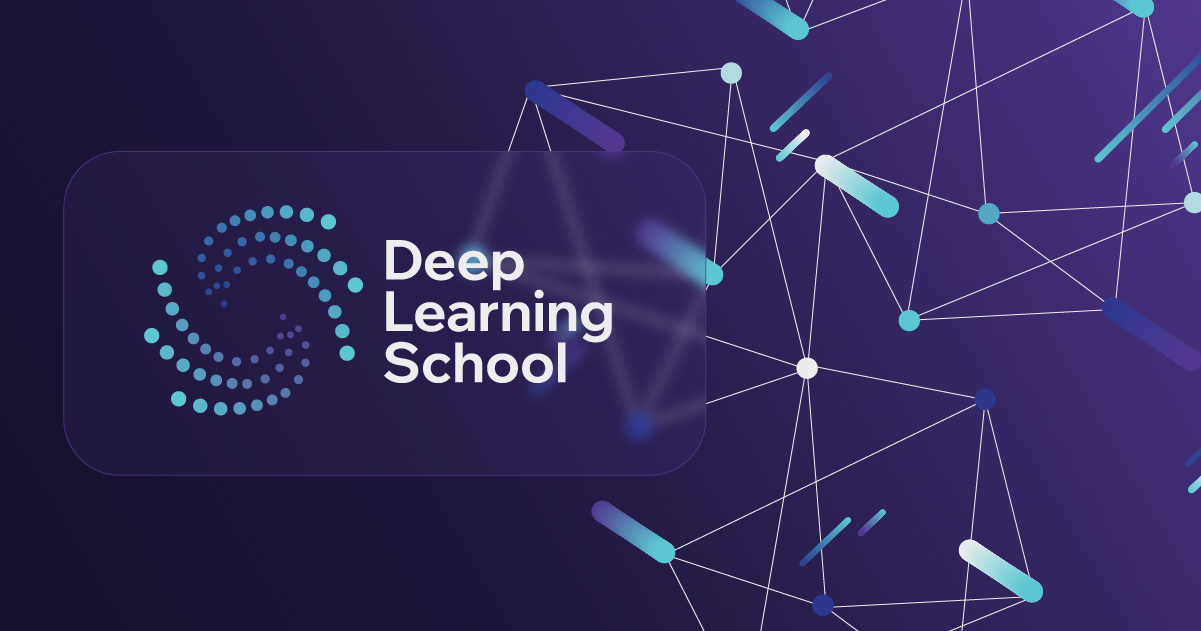

<h1 style="text-align: center;"><b>Customer Churn Prediction</b></h1>


Проект по бинарной классификации оттока клиентов на табличных данных.


# Метрика

Основная метрика качества в проекте - ROC-AUC.


In [ ]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

np.float64(0.8333333333333333)

# Исследование данных


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

## Загрузка и очистка данных


In [ ]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 111MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 68.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 25.0MB/s]


In [ ]:
data = pd.read_csv('./train.csv')

In [ ]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [ ]:
data_copy = data.copy()

In [ ]:
data.sample(5)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
4898,1,25.40,25.4,Female,0,No,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
827,24,51.10,1269.6,Male,0,No,No,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Credit card (automatic),0
2757,58,19.55,1108.8,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,0
238,53,62.85,3419.5,Male,0,No,Yes,Yes,No,DSL,Yes,Yes,No,Yes,No,No,One year,No,Credit card (automatic),0
356,33,90.65,2989.6,Female,0,No,No,Yes,Yes,Fiber optic,Yes,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,0


In [ ]:
data.dtypes

,0
ClientPeriod,int64
MonthlySpending,float64
TotalSpent,object
Sex,object
IsSeniorCitizen,int64
HasPartner,object
HasChild,object
HasPhoneService,object
HasMultiplePhoneNumbers,object
HasInternetService,object


In [ ]:
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
data.eq('No internet service').sum(axis=0)

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


Явных `NaN` немного, но часть значений `no internet service` логически эквивалентна отсутствию услуги.


In [ ]:
data['TotalSpent'].dtype

dtype('O')

## Анализ данных


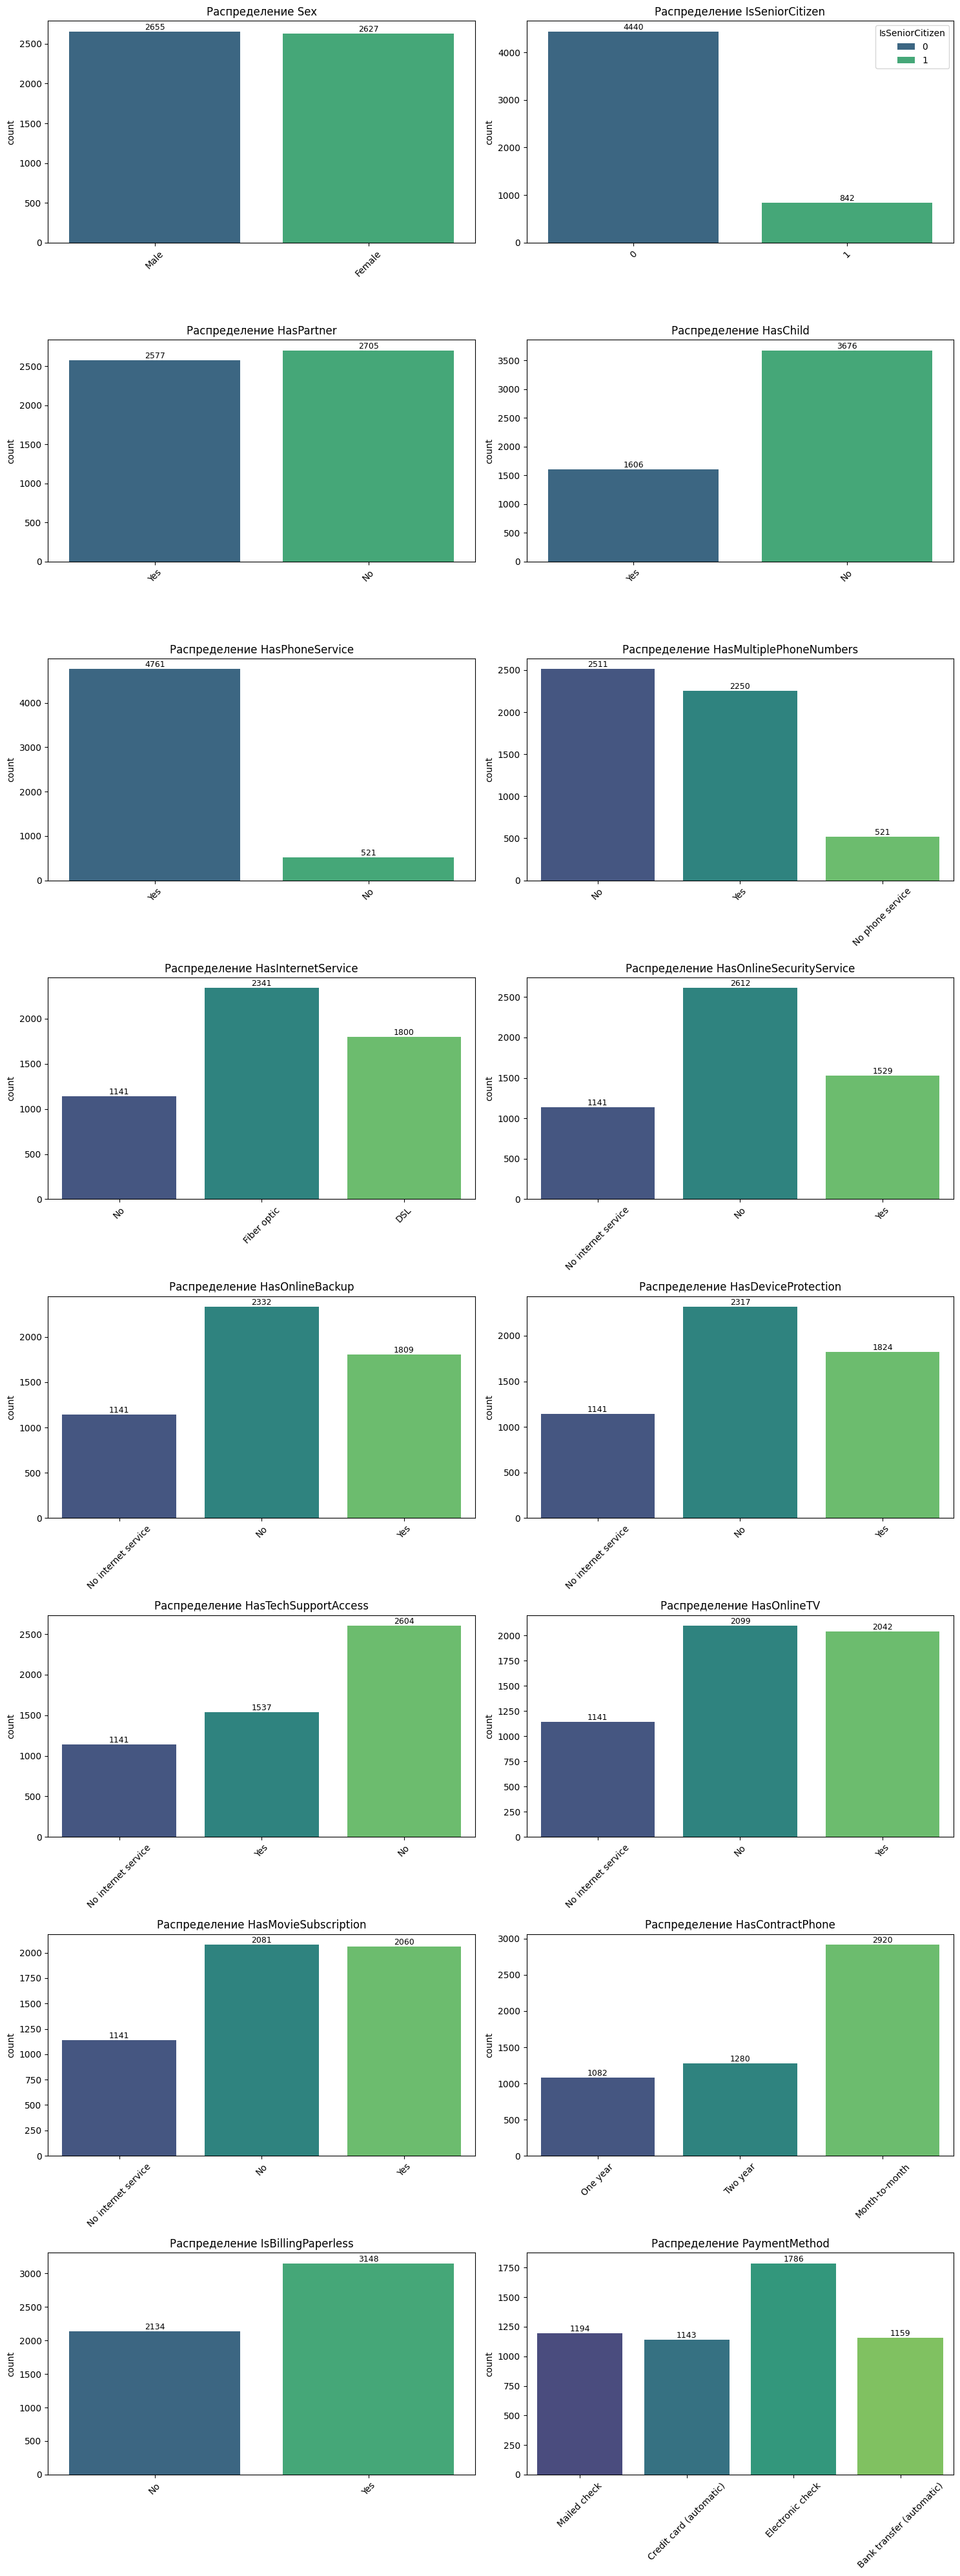

In [ ]:


n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=data, x=col, ax=axes[i], hue=col, palette='viridis')
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=9)


plt.tight_layout()
plt.show()

По распределениям признаков сильного дисбаланса в категориальных переменных не наблюдается.


Признак `TotalSpent` хранится как `object`, поэтому перед обучением перевожу его в `float`.


In [ ]:
data.eq(' ').sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,9
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


Пустые значения в `TotalSpent` встречаются редко, поэтому заменяю их нулями.


In [ ]:
data['TotalSpent'] = data['TotalSpent'].apply(lambda x: float(x) if '.' in x else 0)

In [ ]:
data.eq(' ').sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [ ]:
data['TotalSpent'] = data['TotalSpent'].astype(float)

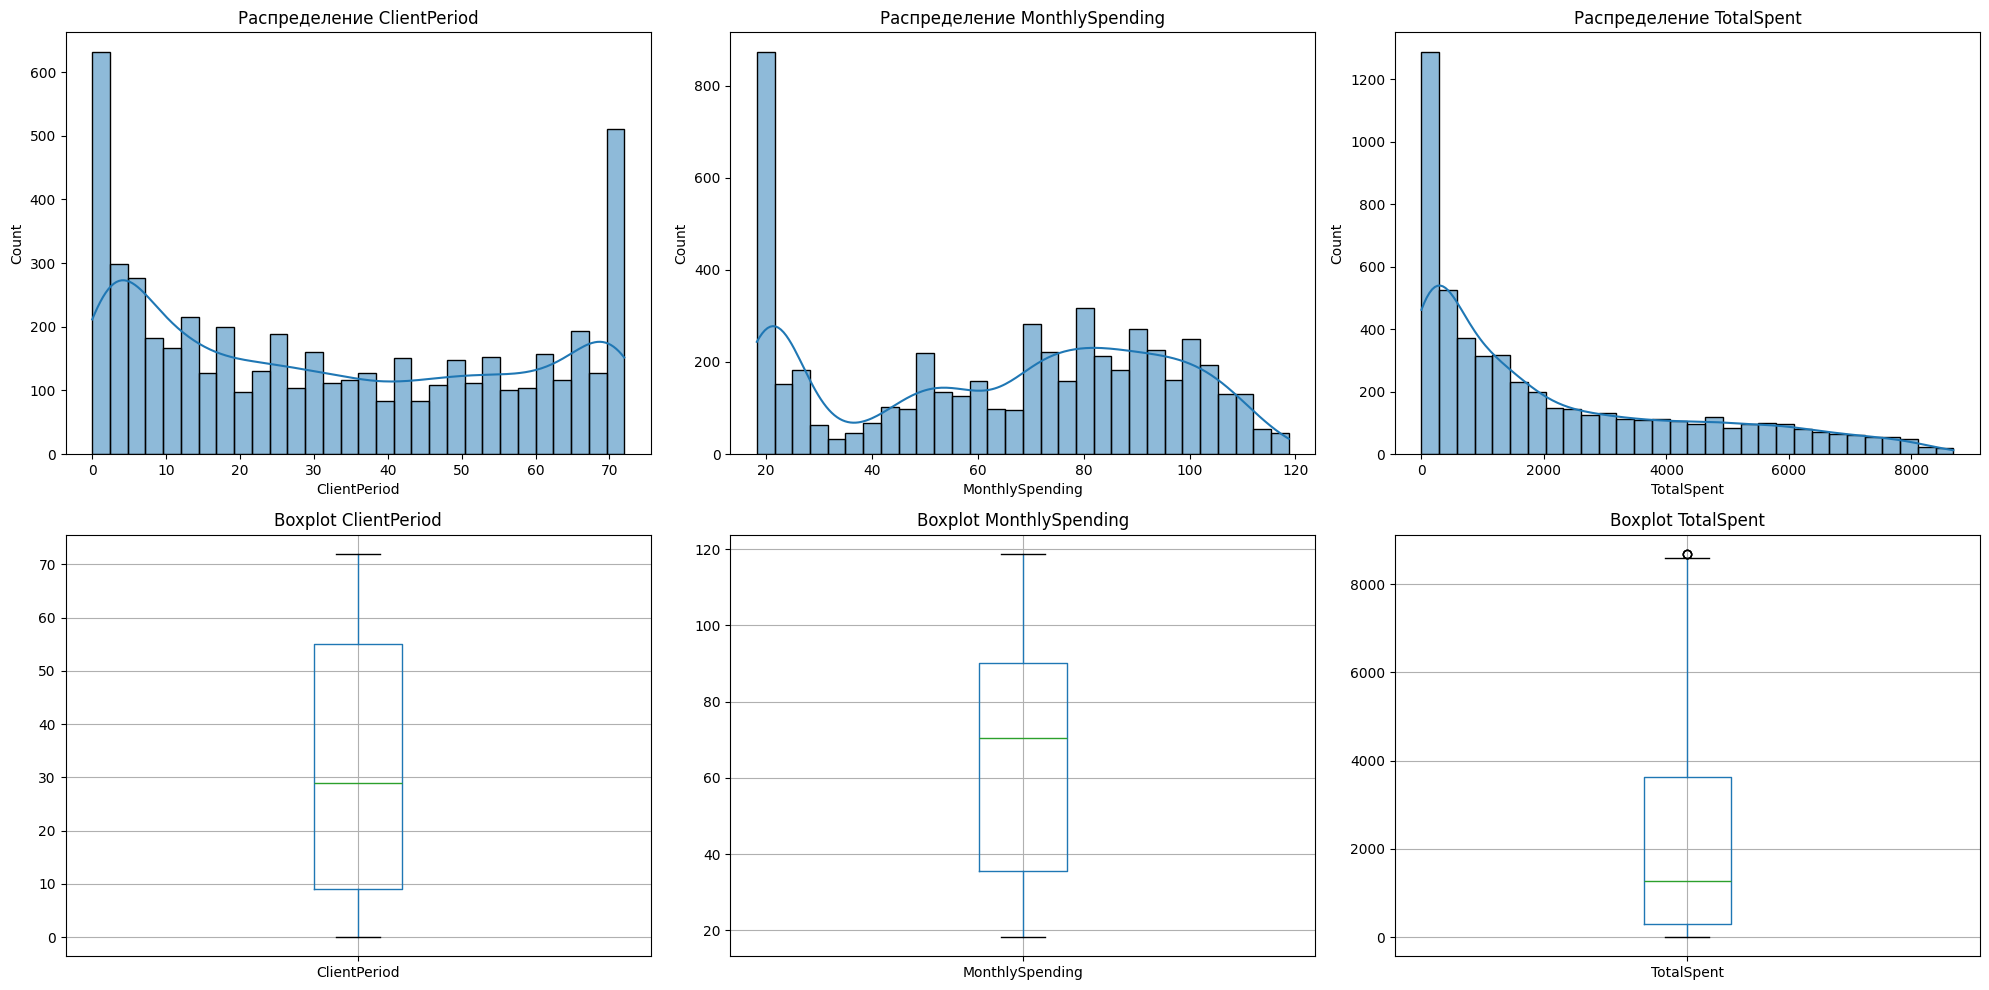

In [ ]:
fig, axes = plt.subplots(2, len(num_cols), figsize=(20, 10))

for i, col in enumerate(num_cols):
    sns.histplot(data=data, x=col, ax=axes[0, i], kde=True, bins=30)
    axes[0, i].set_title(f'Распределение {col}')

    data.boxplot(column=col, ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

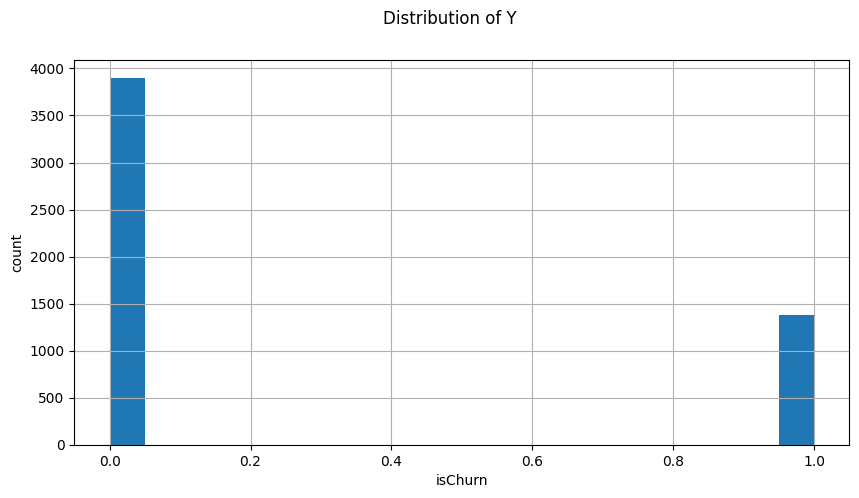

In [ ]:
plt.figure(figsize = (10, 5))

data['Churn'].hist(density=False, bins=20)
plt.ylabel('count')
plt.xlabel('isChurn')

plt.suptitle('Distribution of Y')
plt.show()

Распределение целевой переменной выглядит приемлемо для стандартных методов бинарной классификации.


## Линейная модель


In [ ]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier

In [ ]:
scaler = StandardScaler()

In [ ]:
data[num_cols] = scaler.fit_transform(data[num_cols])

In [ ]:
data_origin = data

In [ ]:
num_data = data[num_cols]

In [ ]:
dummy_features = pd.get_dummies(data[cat_cols])

In [ ]:
X = pd.concat([num_data, dummy_features], axis=1)
X_origin = data.iloc[:, :-1]
X.head()

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,Sex_Female,Sex_Male,HasPartner_No,HasPartner_Yes,HasChild_No,HasChild_Yes,...,HasMovieSubscription_Yes,HasContractPhone_Month-to-month,HasContractPhone_One year,HasContractPhone_Two year,IsBillingPaperless_No,IsBillingPaperless_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.920767,-1.505447,-0.509331,0,False,True,False,True,False,True,...,False,False,True,False,True,False,False,False,False,True
1,1.613288,-1.294998,-0.136902,0,False,True,False,True,True,False,...,False,False,False,True,True,False,False,True,False,False
2,-1.279005,0.363737,-0.927816,0,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False
3,-0.016173,0.476418,-0.961235,1,True,False,False,True,True,False,...,False,True,False,False,True,False,False,False,False,True
4,1.124450,1.667856,2.014521,0,True,False,False,True,False,True,...,True,False,False,True,True,False,False,True,False,False


In [ ]:
y = data['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

In [ ]:
model = LogisticRegressionCV(scoring='roc_auc', max_iter=1000, random_state=42) # YOUR CODE

In [ ]:


model.fit(X_train, y_train)

print(f"Лучший параметр C: {model.C_[0]}")
print(f"Лучшее качество на кросс-валидации (по метрике ROC AUC): {model.scores_[1].max()}")

y_test_predicted = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_test_predicted)
print(f"Качество на тестовой выборке (ROC AUC): {roc_auc}")



Лучший параметр C: 21.54434690031882
Лучшее качество на кросс-валидации (по метрике ROC AUC): 0.8780976642253732
Качество на тестовой выборке (ROC AUC): 0.8308186148338806


In [ ]:
y_train_predicted = model.predict_proba(X_train)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

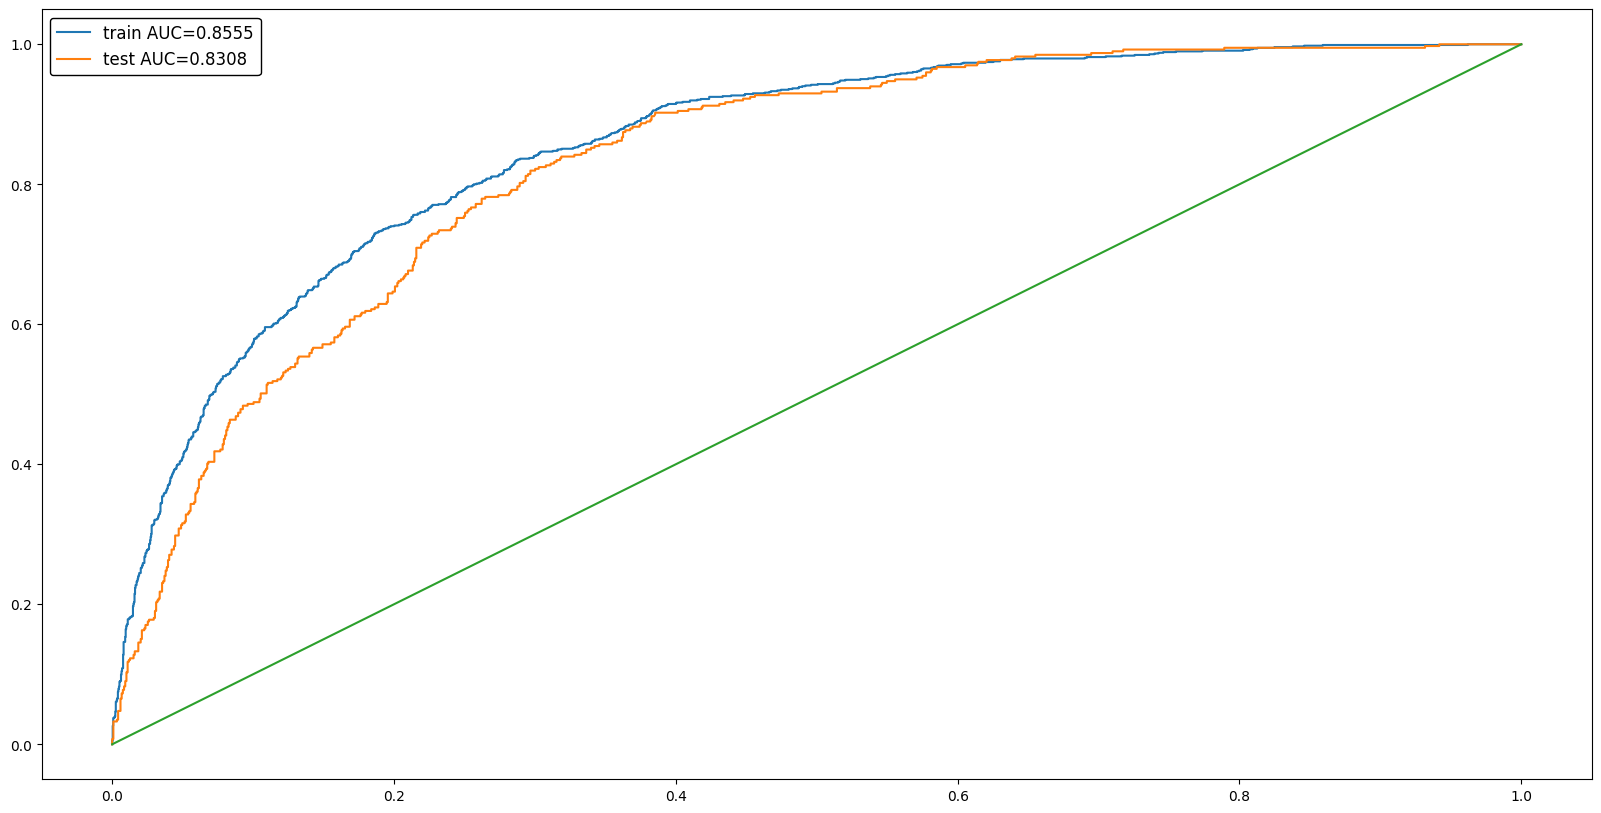

In [ ]:
train_auc = roc_auc_score(y_train, y_train_predicted)
test_auc = roc_auc_score(y_test, y_test_predicted)

plt.figure(figsize=(20,10))
plt.plot(*roc_curve(y_train, y_train_predicted)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_test, y_test_predicted)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.show()

## Градиентный бустинг


In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.8 MB/s eta 0:00:00


In [ ]:
import catboost

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
# CatBoost умеет работать с категориальными признаками сам
X_train_origin, X_test_origin, _, _ = train_test_split(X_origin, y,
                                                       train_size=0.7,
                                                       random_state=42)



In [ ]:
boosting_model = catboost.CatBoostClassifier(n_estimators=200,
                                             cat_features=cat_cols)

boosting_model.fit(X_train_origin, y_train)

y_train_predicted = boosting_model.predict_proba(X_train_origin)[:, 1]
y_test_predicted = boosting_model.predict_proba(X_test_origin)[:, 1]

Learning rate set to 0.07877
0:	learn: 0.6455512	total: 66.4ms	remaining: 13.2s
1:	learn: 0.6109813	total: 81.9ms	remaining: 8.11s
2:	learn: 0.5808307	total: 94.7ms	remaining: 6.22s
3:	learn: 0.5496650	total: 111ms	remaining: 5.42s
4:	learn: 0.5277294	total: 119ms	remaining: 4.65s
5:	learn: 0.5080942	total: 133ms	remaining: 4.31s
6:	learn: 0.4931868	total: 148ms	remaining: 4.07s
7:	learn: 0.4837971	total: 152ms	remaining: 3.66s
8:	learn: 0.4719985	total: 166ms	remaining: 3.52s
9:	learn: 0.4617314	total: 180ms	remaining: 3.43s
10:	learn: 0.4528478	total: 193ms	remaining: 3.32s
11:	learn: 0.4459007	total: 212ms	remaining: 3.32s
12:	learn: 0.4390068	total: 233ms	remaining: 3.35s
13:	learn: 0.4337184	total: 249ms	remaining: 3.31s
14:	learn: 0.4284929	total: 265ms	remaining: 3.27s
15:	learn: 0.4244561	total: 279ms	remaining: 3.21s
16:	learn: 0.4195829	total: 298ms	remaining: 3.2s
17:	learn: 0.4168795	total: 311ms	remaining: 3.14s
18:	learn: 0.4140618	total: 324ms	remaining: 3.09s
19:	learn:

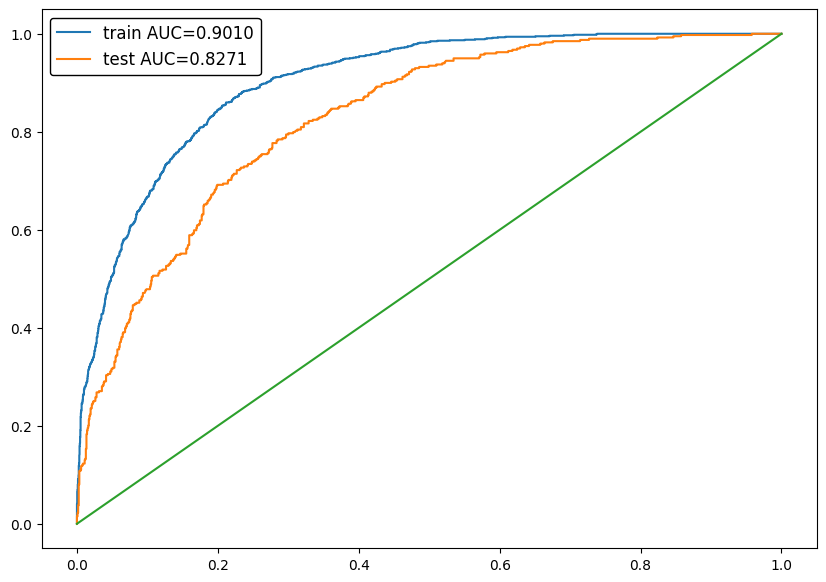

In [ ]:
train_auc = roc_auc_score(y_train, y_train_predicted)
test_auc = roc_auc_score(y_test, y_test_predicted)

plt.figure(figsize=(10,7))
plt.plot(*roc_curve(y_train, y_train_predicted)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_test, y_test_predicted)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.show()

In [ ]:
boosting_model = catboost.CatBoostClassifier(n_estimators=200, silent=True,
                                             cat_features=cat_cols,
                                             eval_metric='AUC')
boosting_model.grid_search({'l2_leaf_reg': np.linspace(0, 1, 20)},
                           X_train_origin,
                           y_train, plot=True, refit=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))


bestTest = 0.8349304764
bestIteration = 72

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
0:	loss: 0.8349305	best: 0.8349305 (0)	total: 2.52s	remaining: 48s

bestTest = 0.8373193526
bestIteration = 157

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
1:	loss: 0.8373194	best: 0.8373194 (1)	total: 6.52s	remaining: 58.7s

bestTest = 0.83567814
bestIteration = 97

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
2:	loss: 0.8356781	best: 0.8373194 (1)	total: 9.04s	remaining: 51.3s

bestTest = 0.8364303624
bestIteration = 177

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
3:	loss: 0.8364304	best: 0.8373194 (1)	total: 11.6s	remaining: 46.6s

bestTest 

{'params': {'l2_leaf_reg': 1},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               45,
               46,
               47,
               48,
 

# Подготовка предсказаний


In [ ]:
best_model = boosting_model

In [ ]:
X_test = pd.read_csv('./test.csv')

In [ ]:
X_test['Churn'] = 0

In [ ]:
X_test['TotalSpent'] = X_test['TotalSpent'].apply(lambda x: float(x) if '.' in x else 0)

In [ ]:
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

In [ ]:
submission = pd.read_csv('./submission.csv')

submission['Churn'] = best_model.predict_proba(X_test)[:, 1]
submission.to_csv('./my_submission.csv')